In [11]:
# 구글 드라이브 연결 
from google.colab import drive
drive.mount('/content/drive')
folder_dir = "/content/drive/MyDrive/Colab Notebooks/"
DATA_FILE = "wine.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 마운트 및 csv파일 출력

import pandas as pd
import os

# 디렉토리 경로와 파일명을 결합하여 파일 시스템 내 절대 경로를 확정
file_path = os.path.join(folder_dir, DATA_FILE)

# CSV 데이터 파싱 및 메모리 내 DataFrame 객체 생성
try:
    df = pd.read_csv(file_path)
    
    # Colab 인터랙티브 환경의 데이터 렌더링 기능을 활용한 출력
    # display(df)
except FileNotFoundError:
    print(f"오류: 지정된 경로에서 파일을 식별할 수 없습니다. ({file_path})")

In [4]:
# 테스트셋, 학습셋 형성
X = df.drop('Wine',axis = 1)
X = X.drop('Alcohol',axis = 1)
display(X)

Y=df['Alcohol']
display(Y)

## 테스트 집단 추출

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.25,random_state=0)

,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...
173,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


,Alcohol
0,14.23
1,13.20
2,13.16
3,14.37
4,13.24
...,...
173,13.71
174,13.40
175,13.27
176,13.17


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



In [6]:


wineLinearRegression = LinearRegression()
wineLinearRegression.fit(X_train, Y_train)
predLinearRegression = wineLinearRegression.predict(X_test)

print('평균제곱근오차', mean_squared_error(predLinearRegression, Y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(predLinearRegression, Y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(predLinearRegression, Y_test))

평균제곱근오차 0.4016852023007239
평균제곱근오차 0.4016852023007239
평균제곱근오차 0.40168520230072396


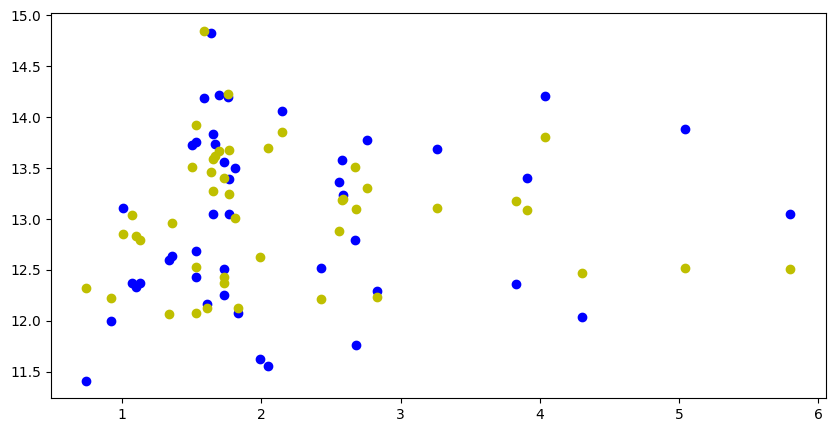

In [7]:
# 예측값과 실제 값 차이를 산접도로 표시, 노란색 예측

plt.figure(figsize=(10,5))
plt.scatter(X_test['Malic.acid'], Y_test, c='b',label='Y_test')
plt.scatter(X_test['Malic.acid'], predLinearRegression, c='y', label='predLinearRegression')
#plt.plot(X_train, lr.predict(X_train), color='blue')
plt.show()

In [8]:


wineDecisionTreeRegressor = DecisionTreeRegressor()
wineDecisionTreeRegressor.fit(X_train, Y_train)
predDecisionTreeRegressor = wineDecisionTreeRegressor.predict(X_test)

print('평균제곱근오차', mean_squared_error(predDecisionTreeRegressor, Y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(predDecisionTreeRegressor, Y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(predDecisionTreeRegressor, Y_test))

평균제곱근오차 0.6550222222222224
평균제곱근오차 0.6550222222222224
평균제곱근오차 0.6550222222222222


In [9]:


wineRandomForestRegressor = RandomForestRegressor()
wineRandomForestRegressor.fit(X_train, Y_train)
predRandomForestRegressor = wineRandomForestRegressor.predict(X_test)

print('평균제곱근오차', mean_squared_error(predRandomForestRegressor, Y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(predRandomForestRegressor, Y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(predRandomForestRegressor, Y_test))

평균제곱근오차 0.46456105311111
평균제곱근오차 0.46456105311111
평균제곱근오차 0.46456105311110985


In [10]:


wineSVR = SVR()
wineSVR.fit(X_train, Y_train)
predSVR = wineSVR.predict(X_test)

print('평균제곱근오차', mean_squared_error(predSVR, Y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(predSVR, Y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(predSVR, Y_test))

평균제곱근오차 0.3068033111166366
평균제곱근오차 0.3068033111166366
평균제곱근오차 0.3068033111166366
